In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uttamkantidutta/amazon-processed/amazon_electronics_processed.csv


In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("/kaggle/input/datasets/uttamkantidutta/amazon-processed/amazon_electronics_processed.csv")

df           

,Review_Text,Processed_Text,Sentiment,Product_ID,Product_Category,Rating,Review_Month,Helpful_Votes,Verified_Purchase
0,This is my 3td kindle and I love being able to...,3td kindle love able book,Positive,B07T6XMZQZ,Computers,4,2021-11,0,True
1,Build quality is fine and the Windows 11 came ...,build quality fine window 11 came running micr...,Negative,B0C7KBYGN4,Computers,2,2023-01,0,True
2,Would not connect to my computer even with tec...,not connect computer tech support help,Negative,B09G9STJF6,Computers,1,2023-02,0,True
3,"Like most lenses with bulbous front element, u...",like lens bulbous element using filter not ava...,Positive,B01738GIQG,Camera & Photo,5,2022-05,0,True
4,Work perfectly.,work perfectly,Positive,B000NK5Z8Y,Camera & Photo,5,2016-01,0,True
...,...,...,...,...,...,...,...,...,...
199642,"The sound was good, but I had to return them. ...",sound good return not stay ear hadnt exercised...,Negative,B00WSM6W8W,Home Audio & Theater,2,2014-07,0,True
199643,The laptop is great. Plays just about everyth...,laptop great play just steam account highest r...,Positive,B09J2BCP87,Computers,4,2022-04,1,True
199644,This amplifier is exactly what I was looking f...,amplifier exactly looking small simple powerfu...,Positive,B07Q41YB14,All Electronics,5,2021-01,0,True
199645,My high school son is impressed with everythin...,high school son impressed tool msword function...,Positive,B00FFVYSMK,Computers,5,2014-01,1,True


In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    df["Processed_Text"],
    df["Sentiment"],
    test_size = 0.20,
    random_state = 42,
    stratify = df["Sentiment"]
)

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 159717
Testing : 39930


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train

array([2, 2, 0, ..., 1, 2, 0])

In [9]:
sentences_train = X_train.str.split().tolist()

print("Number of sentences:", len(sentences_train))
print("\nExample:")
print(sentences_train[0][:20])

Number of sentences: 159717

Example:
['good', 'cable', 'work']


In [10]:
#Train my own CBOW Word2Vec model

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences = sentences_train,
    vector_size = 100,
    window = 5,
    min_count = 5,
    workers=4,
    sg=0,
    epochs=10,
    seed=42
)

In [11]:
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 16724


In [12]:
print(w2v_model.wv.index_to_key[:30])

['not', 'great', 'work', 'good', 'use', 'just', 'like', 'product', 'no', 'sound', 'quality', 'time', 'easy', 'love', 'doe', 'case', 'price', 'camera', 'did', 'really', 'bought', 'cable', 'fit', 'im', 'battery', 'need', 'nice', 'tv', 'used', 'little']


In [13]:
vector = w2v_model.wv["battery"]

print(vector)
print("Vector shape:", vector.shape)

[-1.9475536   0.32045722  2.5057302   1.3882992   0.48354417  0.7041201
  0.10469348  0.9558552  -1.4321998  -1.6462821   1.9254444  -3.2558959
  2.2311404   1.6204492  -1.2917103   0.42130613  0.7871702   1.8358423
 -0.81103426 -1.8309721  -3.2807596  -1.4890678  -3.803625    4.973995
 -0.0661785   2.855554   -1.4454799  -1.2807374   1.1085297   0.7661287
 -1.289679    0.11047327  0.47826952 -1.7817845  -0.01589264  2.1699142
 -0.01178729  1.8912963   2.1288962  -4.331319   -0.5705112   0.25032908
 -2.333894   -1.4121977   0.10027406  2.8498547  -0.8952981   2.0164504
 -0.72341156 -0.5312715  -0.07749087  3.1083398   0.37666187 -2.7828734
  2.4938881   0.4585543   1.4750587  -0.34569556  1.0868195  -2.9672382
 -2.3215182   0.25194108  0.85307515 -2.6109097   1.0100884  -0.38238436
 -2.2665677   2.26699     2.274363   -0.685865    2.7937155   1.6297545
 -0.2690384  -1.7876068  -1.6945124   0.6156396  -1.6479602  -1.3602674
 -0.69025576 -1.6608651  -0.58363926  0.48601082 -1.2513146  -1

In [14]:
w2v_model.wv.most_similar("battery",topn = 10)

[('batter', 0.7730386853218079),
 ('aaa', 0.6029977798461914),
 ('expectancy', 0.60026615858078),
 ('span', 0.5998480319976807),
 ('aa', 0.5765935778617859),
 ('recharge', 0.5581586956977844),
 ('nimh', 0.5554414987564087),
 ('charge', 0.5536361336708069),
 ('charged', 0.5488204956054688),
 ('lithium', 0.5184156894683838)]

In [15]:
w2v_model.wv.most_similar("sound", topn=10)

[('sounding', 0.7454696297645569),
 ('audio', 0.6935243010520935),
 ('bass', 0.6872923970222473),
 ('sounded', 0.668395459651947),
 ('loud', 0.6105369925498962),
 ('loudness', 0.6092283725738525),
 ('treble', 0.6061162948608398),
 ('vocal', 0.6039710640907288),
 ('anc', 0.5887848138809204),
 ('speaker', 0.5841848254203796)]

In [16]:
w2v_model.wv.most_similar("charger", topn=10)

[('charging', 0.716698169708252),
 ('charge', 0.6988698244094849),
 ('recharging', 0.5853819847106934),
 ('recharge', 0.5579266548156738),
 ('microusb', 0.5530471801757812),
 ('charged', 0.551480770111084),
 ('cord', 0.5314297676086426),
 ('outlet', 0.5245182514190674),
 ('adaptor', 0.5114675760269165),
 ('adapter', 0.5061864852905273)]

In [17]:
w2v_model.wv.similarity("battery", "charger")

np.float32(0.43976888)

In [18]:
w2v_model.wv.similarity("battery", "sound")

np.float32(0.08152673)

In [19]:
#visualize the 100-dimensional vectors

words = [
    "battery",
    "charger",
    "charging",
    "sound",
    "speaker",
    "quality",
    "cable",
    "screen",
    "camera",
    "laptop",
    "keyboard",
    "mouse",
    "product",
    "price",
    "device"
]

# Keep only words that exist in the Word2Vec vocabulary
words = [
    word for word in words
    if word in w2v_model.wv.key_to_index
]

print(words)

['battery', 'charger', 'charging', 'sound', 'speaker', 'quality', 'cable', 'screen', 'camera', 'laptop', 'keyboard', 'mouse', 'product', 'price', 'device']


In [20]:
import numpy as np

embedding_matrix = np.array([
    w2v_model.wv[word]
    for word in words
])

print("Shape:", embedding_matrix.shape)

Shape: (15, 100)


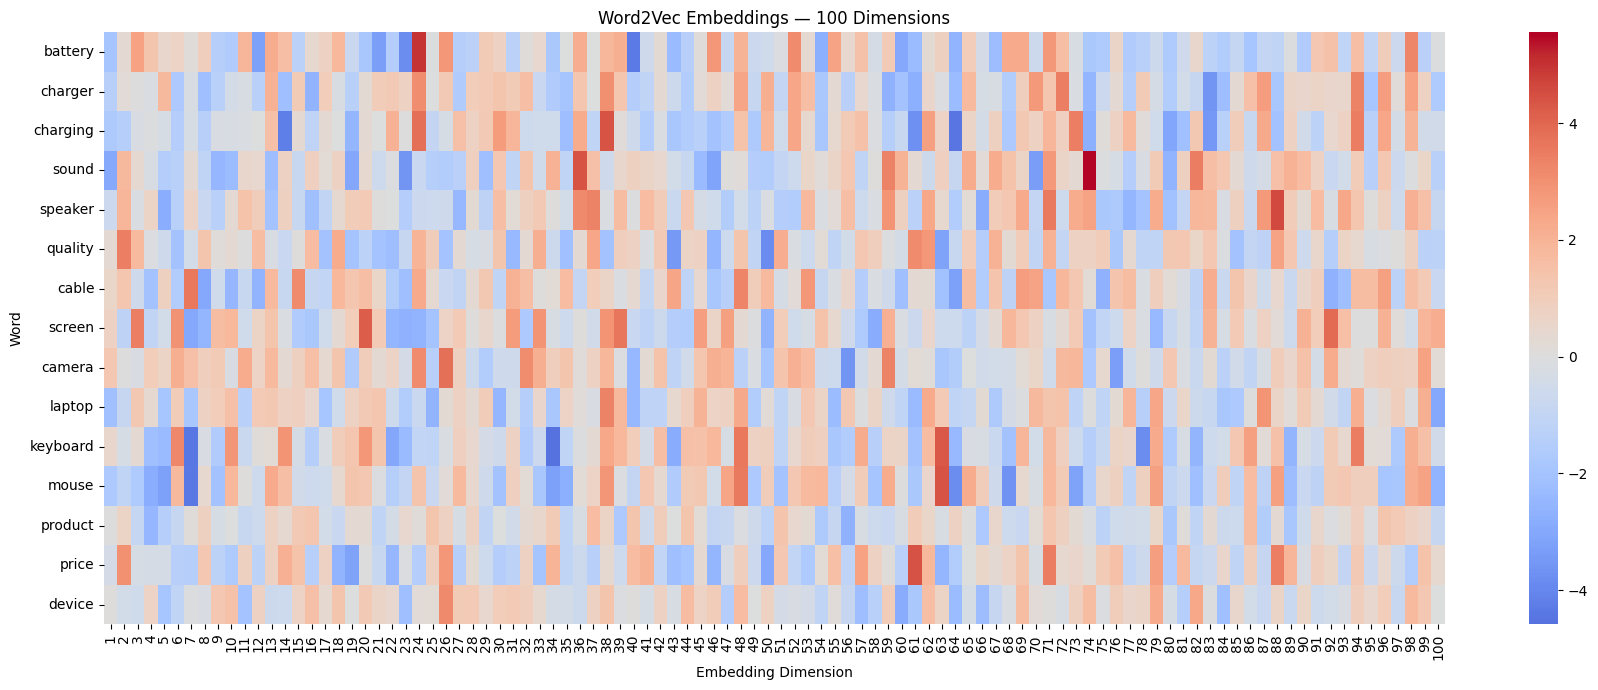

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 7))

sns.heatmap(
    embedding_matrix,
    xticklabels=range(1, 101),
    yticklabels=words,
    cmap="coolwarm",
    center=0
)

plt.title("Word2Vec Embeddings — 100 Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

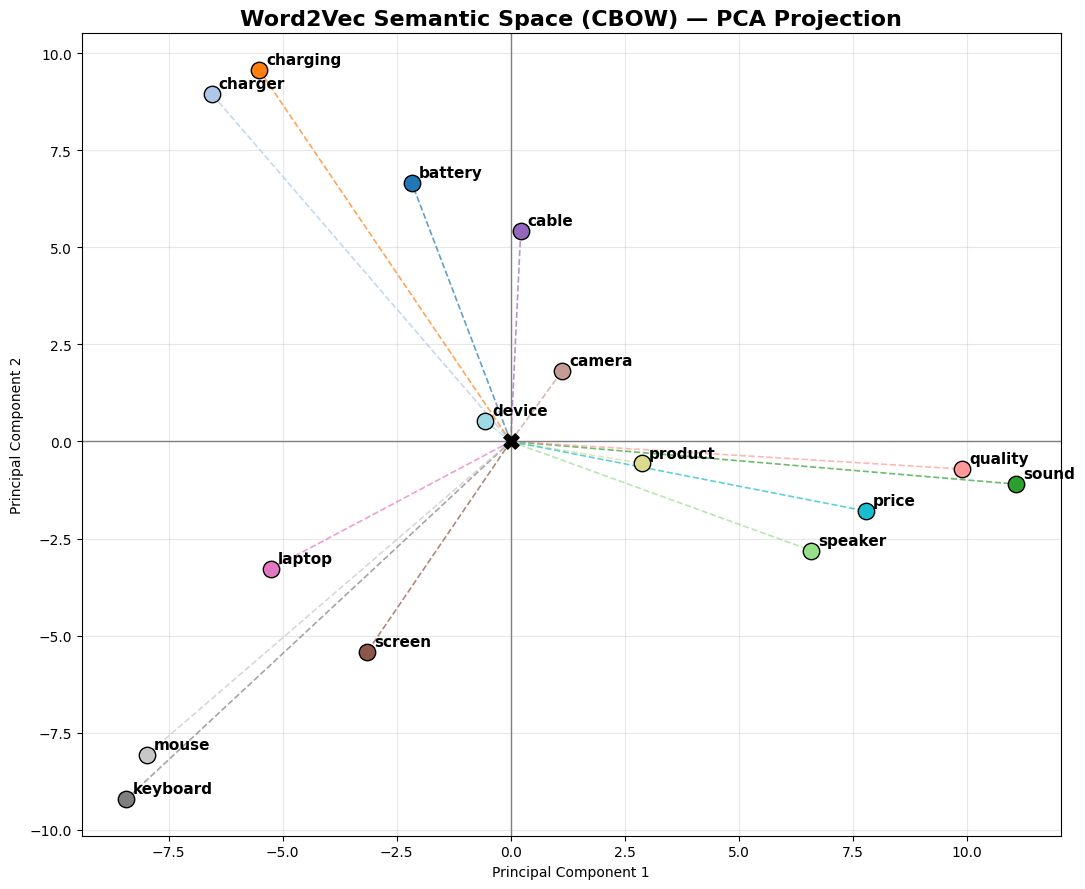

In [22]:
#PCA vusalization of the embeddings

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embedding_matrix)

plt.figure(figsize=(11,9))

# Different colors
colors = plt.cm.tab20(np.linspace(0,1,len(words)))

# Origin
plt.scatter(0,0,color='black',s=120,marker='X',label='Origin',zorder=5)

for i, word in enumerate(words):

    # line from origin
    plt.plot(
        [0,vectors_2d[i,0]],
        [0,vectors_2d[i,1]],
        linestyle='--',
        linewidth=1.2,
        color=colors[i],
        alpha=0.7
    )

    # point
    plt.scatter(
        vectors_2d[i,0],
        vectors_2d[i,1],
        s=140,
        color=colors[i],
        edgecolor='black',
        zorder=3
    )

    # label
    plt.text(
        vectors_2d[i,0]+0.15,
        vectors_2d[i,1]+0.15,
        word,
        fontsize=11,
        weight='bold'
    )

plt.axhline(0,color='gray',linewidth=1)
plt.axvline(0,color='gray',linewidth=1)

plt.grid(alpha=0.3)
plt.title(
    "Word2Vec Semantic Space (CBOW) — PCA Projection",
    fontsize=16,
    weight='bold'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [23]:
# # ============================================================
# # Word2Vec Embedding Visualization — 3D PCA
# # ============================================================

# from sklearn.decomposition import PCA
# import numpy as np
# import plotly.graph_objects as go

# # ------------------------------------------------------------
# # 1. Reduce 100D Word2Vec vectors → 3D
# # ------------------------------------------------------------

# pca_3d = PCA(n_components=3)

# vectors_3d = pca_3d.fit_transform(embedding_matrix)

# explained_variance = pca_3d.explained_variance_ratio_

# print(f"PC1 explained variance: {explained_variance[0]:.2%}")
# print(f"PC2 explained variance: {explained_variance[1]:.2%}")
# print(f"PC3 explained variance: {explained_variance[2]:.2%}")
# print(f"Total explained variance: {explained_variance.sum():.2%}")


# # ------------------------------------------------------------
# # 2. Create colors
# # ------------------------------------------------------------

# colors = np.arange(len(words))


# # ------------------------------------------------------------
# # 3. Create figure
# # ------------------------------------------------------------

# fig = go.Figure()


# # ------------------------------------------------------------
# # 4. Add arrows from origin → each word
# # ------------------------------------------------------------

# for i, word in enumerate(words):

#     x = vectors_3d[i, 0]
#     y = vectors_3d[i, 1]
#     z = vectors_3d[i, 2]

#     # Line from origin to word
#     fig.add_trace(
#         go.Scatter3d(
#             x=[0, x],
#             y=[0, y],
#             z=[0, z],
#             mode="lines",
#             line=dict(
#                 width=4,
#                 color=f"hsl({i * 360 / len(words)}, 80%, 50%)"
#             ),
#             hoverinfo="skip",
#             showlegend=False
#         )
#     )


# # ------------------------------------------------------------
# # 5. Add word points
# # ------------------------------------------------------------

# fig.add_trace(
#     go.Scatter3d(
#         x=vectors_3d[:, 0],
#         y=vectors_3d[:, 1],
#         z=vectors_3d[:, 2],

#         mode="markers+text",

#         text=words,
#         textposition="top center",

#         marker=dict(
#             size=9,
#             color=colors,
#             colorscale="Turbo",
#             showscale=True,
#             colorbar=dict(
#                 title="Word Index"
#             ),
#             line=dict(
#                 width=1,
#                 color="black"
#             ),
#             opacity=0.95
#         ),

#         hovertemplate=(
#             "<b>%{text}</b><br>"
#             "PC1: %{x:.2f}<br>"
#             "PC2: %{y:.2f}<br>"
#             "PC3: %{z:.2f}"
#             "<extra></extra>"
#         ),

#         name="Words"
#     )
# )


# # ------------------------------------------------------------
# # 6. Add origin
# # ------------------------------------------------------------

# fig.add_trace(
#     go.Scatter3d(
#         x=[0],
#         y=[0],
#         z=[0],

#         mode="markers+text",

#         text=["Origin"],
#         textposition="bottom center",

#         marker=dict(
#             size=12,
#             color="black",
#             symbol="diamond"
#         ),

#         showlegend=False
#     )
# )


# # ------------------------------------------------------------
# # 7. Layout
# # ------------------------------------------------------------

# fig.update_layout(

#     title=dict(
#         text="Interactive 3D Word2Vec Semantic Space — CBOW",
#         x=0.5,
#         font=dict(
#             size=22
#         )
#     ),

#     scene=dict(

#         xaxis=dict(
#             title=f"PC1 ({explained_variance[0]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         yaxis=dict(
#             title=f"PC2 ({explained_variance[1]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         zaxis=dict(
#             title=f"PC3 ({explained_variance[2]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         bgcolor="white"
#     ),

#     width=1100,
#     height=850,

#     margin=dict(
#         l=0,
#         r=0,
#         b=0,
#         t=70
#     )
# )

# import plotly.io as pio

# pio.renderers.default = "iframe"

# fig.show()

In [24]:
from collections import Counter

all_words = [word for sentence in sentences_train for word in sentence ]

word_counts = Counter(all_words)

In [25]:
top_100_words = [
    word 
    for word,count in word_counts.most_common(100)
    if word in w2v_model.wv.key_to_index
]

print("Number of words:", len(top_100_words))
print(top_100_words[:40])

Number of words: 100
['not', 'great', 'work', 'good', 'use', 'just', 'like', 'product', 'no', 'sound', 'quality', 'time', 'easy', 'love', 'doe', 'case', 'price', 'camera', 'did', 'really', 'bought', 'cable', 'fit', 'im', 'battery', 'need', 'nice', 'tv', 'used', 'little', 'using', 'phone', 'better', 'buy', 'device', 'thing', 'got', 'make', 'screen', 'problem']


In [26]:
embedding_matrix_100 = []

for i in top_100_words:
    embedding_matrix_100.append(w2v_model.wv[i])
embedding_matrix_100 = np.array(embedding_matrix_100)

print("Shape:", embedding_matrix_100.shape)
print(embedding_matrix_100)

Shape: (100, 100)
[[-1.4183453e+00  1.3984575e+00  1.1720350e+00 ...  2.9794249e-01
   1.6273189e-02 -6.8605715e-01]
 [ 7.1012020e-01 -1.0978763e+00  5.9881461e-01 ... -1.3066952e+00
   8.6857082e-04 -5.1421630e-01]
 [ 1.3554455e+00 -7.9305887e-01  7.7257681e-01 ...  1.3351260e-01
   1.1369505e+00 -1.0659664e+00]
 ...
 [ 6.0290861e-01 -2.2760725e+00  2.2870221e+00 ...  1.6861591e+00
   2.0183759e+00 -1.6103927e+00]
 [ 2.5581911e+00  7.1149147e-01 -5.9085047e-01 ...  1.3448070e-01
  -8.6657047e-01 -1.7135969e+00]
 [-3.7193295e-01 -3.0903106e+00 -5.0045925e-01 ... -2.8490448e-01
   2.2030470e+00  1.4285564e+00]]


PC1 explained variance: 7.19%
PC2 explained variance: 5.64%
Total explained variance: 12.83%


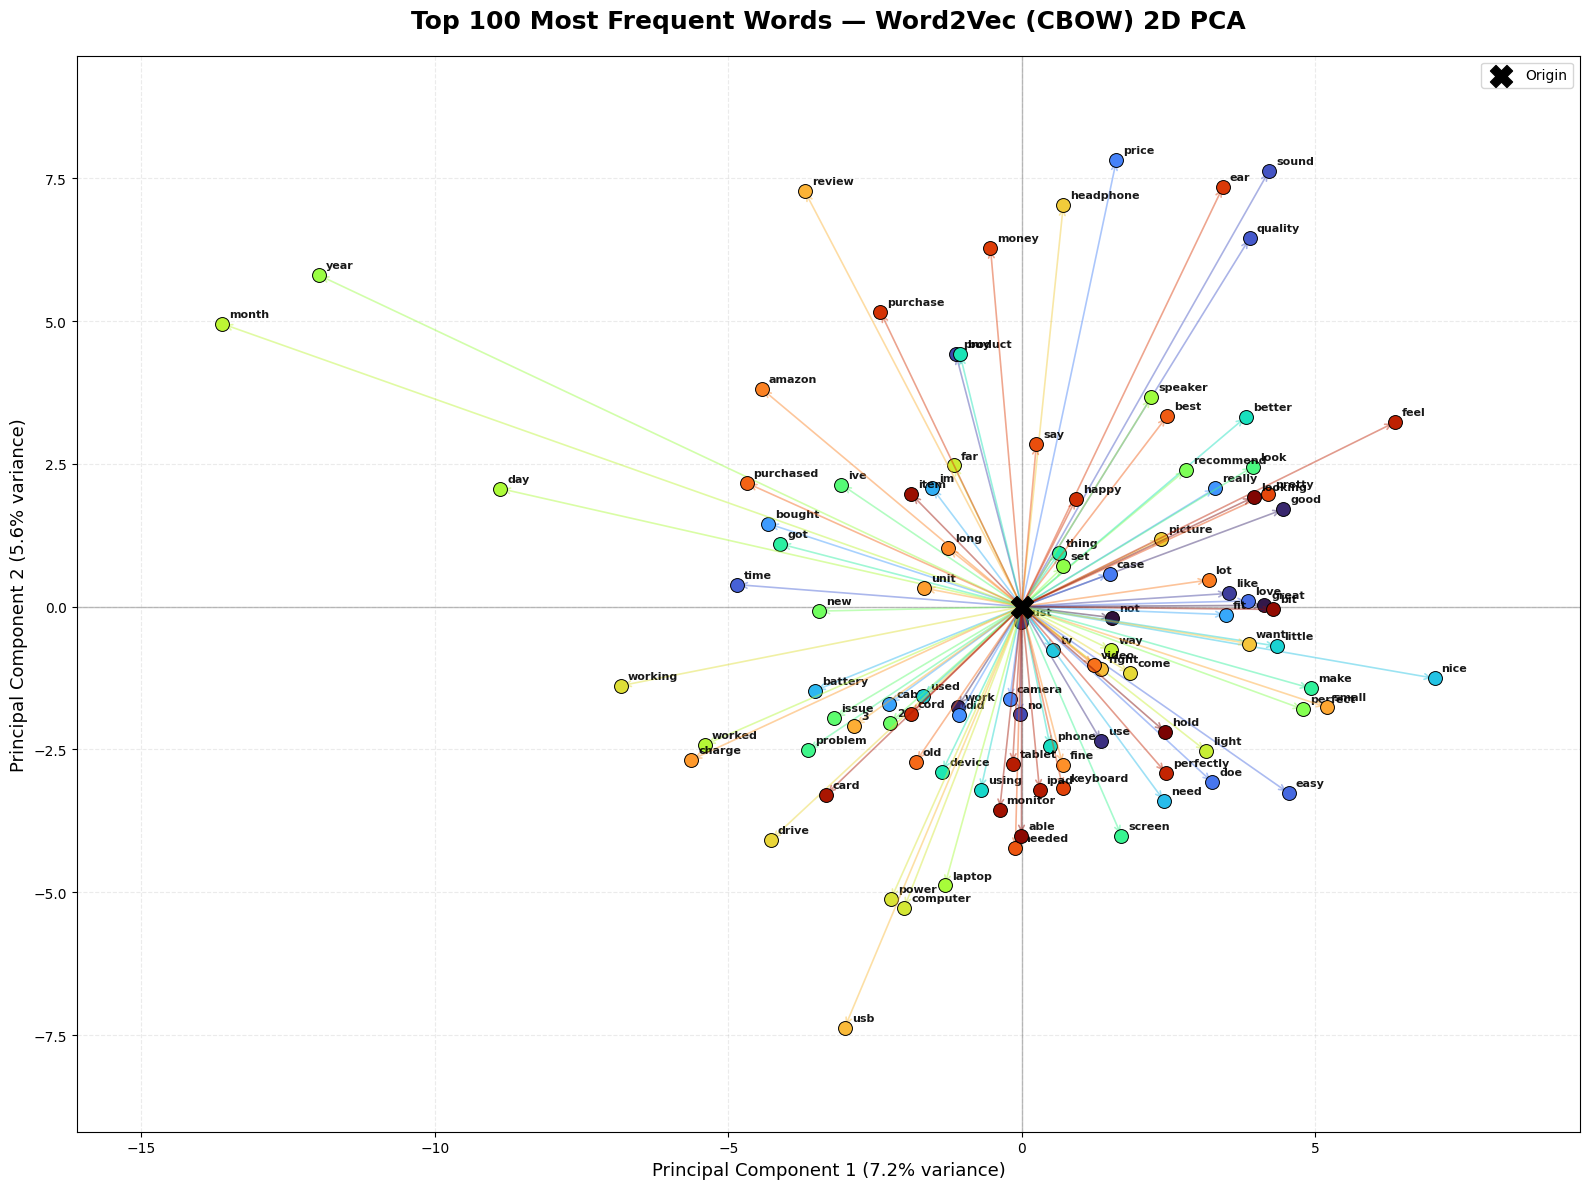

In [27]:
# ============================================================
# Word2Vec — Top 100 Words | 2D PCA Visualization
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. PCA: 100 dimensions → 2 dimensions
# ------------------------------------------------------------

pca_100 = PCA(n_components=2)

vectors_100_2d = pca_100.fit_transform(
    embedding_matrix_100
)

explained_variance = pca_100.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")


# ------------------------------------------------------------
# 2. Colors for the 100 words
# ------------------------------------------------------------

colors = plt.cm.turbo(
    np.linspace(0, 1, len(top_100_words))
)


# ------------------------------------------------------------
# 3. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 12))


# ------------------------------------------------------------
# 4. Plot arrows + points + labels
# ------------------------------------------------------------

for i, word in enumerate(top_100_words):

    x = vectors_100_2d[i, 0]
    y = vectors_100_2d[i, 1]

    # Arrow from origin to embedding position
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="->",
            color=colors[i],
            linewidth=1.2,
            alpha=0.45
        )
    )

    # Word point
    ax.scatter(
        x,
        y,
        s=100,
        color=colors[i],
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    # Word label
    ax.annotate(
        word,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        alpha=0.9
    )


# ------------------------------------------------------------
# 5. Origin
# ------------------------------------------------------------

ax.scatter(
    0,
    0,
    s=250,
    color="black",
    marker="X",
    zorder=5,
    label="Origin"
)


# ------------------------------------------------------------
# 6. Axes
# ------------------------------------------------------------

ax.axhline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)

ax.axvline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

ax.set_title(
    "Top 100 Most Frequent Words — Word2Vec (CBOW) 2D PCA",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0]:.1%} variance)",
    fontsize=13
)

ax.set_ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1]:.1%} variance)",
    fontsize=13
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.legend()

ax.margins(0.12)

plt.tight_layout()
plt.show()

In [28]:
w2v_model.wv.most_similar(["good"],topn = 10)

[('decent', 0.8342223763465881),
 ('great', 0.819757342338562),
 ('excellent', 0.7115588188171387),
 ('nice', 0.6639326810836792),
 ('awesome', 0.6478332877159119),
 ('fantastic', 0.6290482878684998),
 ('ok', 0.6280487775802612),
 ('impressive', 0.6262535452842712),
 ('wise', 0.5863093137741089),
 ('amazing', 0.5750611424446106)]

In [29]:
w2v_model.wv.most_similar(["worst"],topn = 10)

[('best', 0.6885650157928467),
 ('terrible', 0.551120400428772),
 ('worse', 0.5447012782096863),
 ('ive', 0.5158974528312683),
 ('garbage', 0.5118070840835571),
 ('horrible', 0.5081269145011902),
 ('awful', 0.49910691380500793),
 ('past', 0.48797762393951416),
 ('never', 0.4527645409107208),
 ('junk', 0.44918182492256165)]

In [30]:
w2v_model.save("amazon_electronics_cbow_word2vec.model")

In [31]:
from gensim.models import Word2Vec

test_model = Word2Vec.load(
    "amazon_electronics_cbow_word2vec.model"
)

print("Vocabulary size:", len(test_model.wv))
print("Vector size:", test_model.wv.vector_size)

Vocabulary size: 16724
Vector size: 100


In [32]:
w2v_model.wv.save_word2vec_format(
    "amazon_electronics_cbow_vectors.txt",
    binary=False
)

#WORD_2_VEC is done here 

In [33]:
# Word2Vec vocabulary to Integer encoding here
word_to_index = {
    word: idx + 1
    for idx, word in enumerate(w2v_model.wv.index_to_key)
}

print("Vocabulary size:", len(word_to_index))

# Check a few words
for word in ["battery", "charger", "sound", "quality"]:
    if word in word_to_index:
        print(word, "→", word_to_index[word])

Vocabulary size: 16724
battery → 25
charger → 143
sound → 10
quality → 11


In [34]:
def text_to_sequence(text):
    return [
        word_to_index[word]
        for word in str(text).split()
        if word in word_to_index
    ]

X_train_seq = X_train.apply(text_to_sequence)
X_test_seq = X_test.apply(text_to_sequence)

print(X_train_seq.iloc[0])

[4, 22, 3]


In [35]:
import numpy as np

train_lengths = X_train_seq.apply(len)

print(train_lengths.describe())

print("\nPercentiles:")
print(
    train_lengths.quantile(
        [0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

count    159717.000000
mean         20.848019
std          34.422842
min           0.000000
25%           5.000000
50%          11.000000
75%          24.000000
max        1818.000000
Name: Processed_Text, dtype: float64

Percentiles:
0.900     47.000
0.950     71.000
0.990    157.000
0.995    208.000
0.999    367.284
Name: Processed_Text, dtype: float64


In [36]:
#padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 100

X_train_padded = pad_sequences(
    X_train_seq.tolist(),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_seq.tolist(),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_padded.shape)
print("Testing shape :", X_test_padded.shape)

Training shape: (159717, 100)
Testing shape : (39930, 100)


In [37]:
#Word2vec embedding matrix
import numpy as np

vocab_size = len(word_to_index) + 1
embedding_dim = w2v_model.wv.vector_size

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim),
    dtype=np.float32
)

for word, index in word_to_index.items():

    embedding_matrix[index] = w2v_model.wv[word]

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)
print("Embedding matrix shape:", embedding_matrix.shape)

Vocabulary size: 16725
Embedding dimension: 100
Embedding matrix shape: (16725, 100)


In [38]:
word = "battery"

idx = word_to_index[word]

print("Word:", word)
print("Index:", idx)

print("\nWord2Vec vector:")
print(w2v_model.wv[word][:10])

print("\nEmbedding matrix vector:")
print(embedding_matrix[idx][:10])

Word: battery
Index: 25

Word2Vec vector:
[-1.9475536   0.32045722  2.5057302   1.3882992   0.48354417  0.7041201
  0.10469348  0.9558552  -1.4321998  -1.6462821 ]

Embedding matrix vector:
[-1.9475536   0.32045722  2.5057302   1.3882992   0.48354417  0.7041201
  0.10469348  0.9558552  -1.4321998  -1.6462821 ]


# ***NN Training parts starts from Here***

In [39]:
#Actuall Neural Network mannn 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding , SimpleRNN,LSTM,GRU,Bidirectional, Dense, Dropout

# **SimpleRNN + Word2Vec(Frozen)**

In [40]:
#SimpleRNN + Word2Vec

from tensorflow.keras.layers import Input

NUM_CLASSES = 3 

#Simple RNN
rnn_model = Sequential([
    Input(shape=(MAX_LEN,)), 
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim,
        weights = [embedding_matrix],
        mask_zero=True, 
        trainable=False
    ),
    SimpleRNN(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

rnn_model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)
rnn_model.summary()

I0000 00:00:1787207832.653870      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787207832.656858      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,199 (6.49 MB)

 Trainable params: 29,699 (116.01 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [41]:
import tensorflow as tf

early_stopping_rnn = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [42]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert the weights array into a dictionary format that Keras requires
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9213612905554152), 1: np.float64(5.111761881901105), 2: np.float64(0.43784592863076)}


In [43]:
history_rnn = rnn_model.fit(
    X_train_padded,
    y_train,
    
    validation_split=0.10,
    
    epochs=10,
    batch_size=128,
    
    class_weight=class_weights,
    
    callbacks=[early_stopping_rnn],
    
    verbose=1
)

Epoch 1/10
   8/1124 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.3333 - loss: 1.6204

I0000 00:00:1787207839.098109     184 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1124/1124 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6437 - loss: 0.9310 - val_accuracy: 0.7492 - val_loss: 0.6412
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6834 - loss: 0.8431 - val_accuracy: 0.6704 - val_loss: 0.7587
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6769 - loss: 0.8401 - val_accuracy: 0.7099 - val_loss: 0.6785


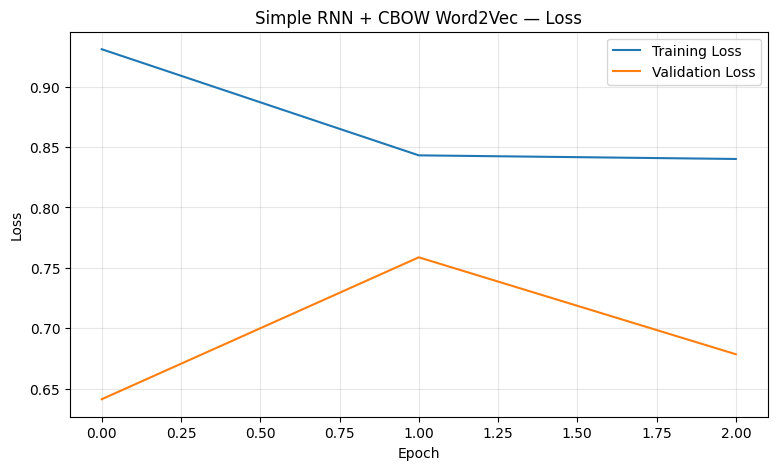

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

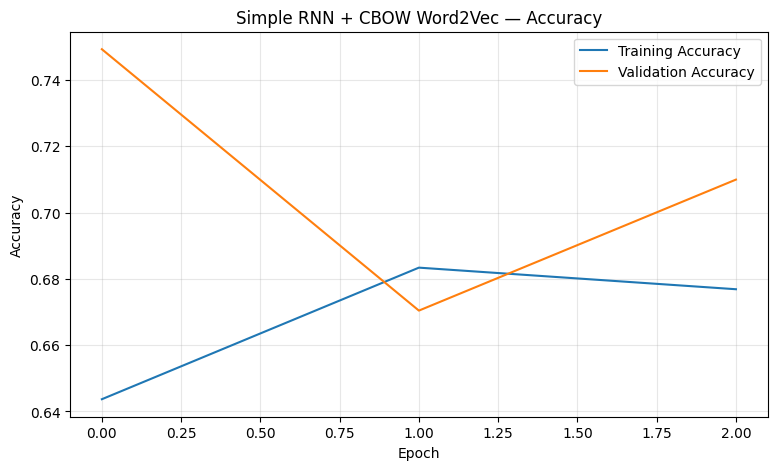

In [45]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_rnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_rnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **LSTM + Word2Vec**

In [46]:
#LSTM + Word2Vec

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

lstm_model = Sequential([
    
    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,790,135 (6.83 MB)

 Trainable params: 117,635 (459.51 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [47]:
early_stopping_lstm = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_lstm],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 391s 342ms/step - accuracy: 0.7189 - loss: 0.7656 - val_accuracy: 0.7374 - val_loss: 0.6139
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 382s 340ms/step - accuracy: 0.7530 - loss: 0.6972 - val_accuracy: 0.7864 - val_loss: 0.5204
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 379s 338ms/step - accuracy: 0.7679 - loss: 0.6700 - val_accuracy: 0.8207 - val_loss: 0.4664
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 379s 338ms/step - accuracy: 0.7791 - loss: 0.6526 - val_accuracy: 0.7975 - val_loss: 0.5135
Epoch 5/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 382s 340ms/step - accuracy: 0.7847 - loss: 0.6380 - val_accuracy: 0.7802 - val_loss: 0.5395


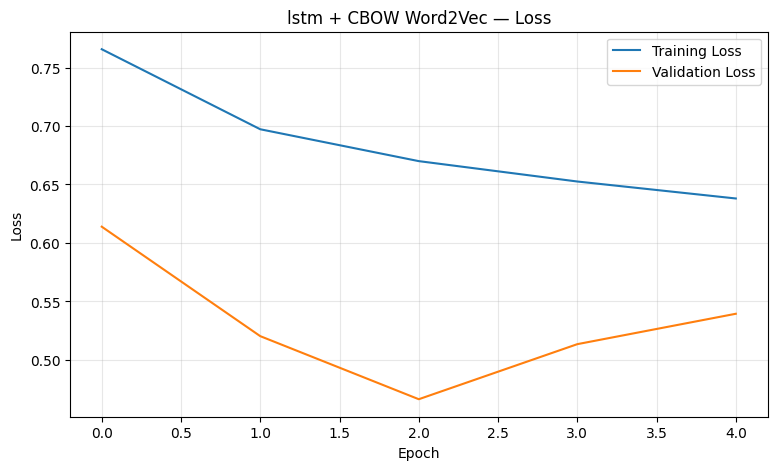

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("lstm + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

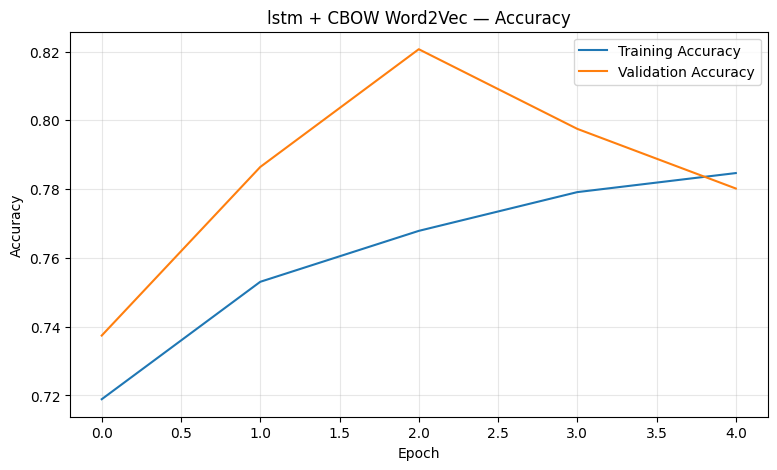

In [49]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("lstm + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **GRU + Word2Vec**

In [50]:
# ============================================================
# GRU + Word2Vec
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GRU,
    Dropout,
    Dense
)

gru_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    GRU(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761,207 (6.72 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [51]:
early_stopping_gru = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_gru = gru_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_gru],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 336s 296ms/step - accuracy: 0.7095 - loss: 0.7861 - val_accuracy: 0.7764 - val_loss: 0.5593
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 329s 293ms/step - accuracy: 0.7565 - loss: 0.6962 - val_accuracy: 0.7940 - val_loss: 0.5190
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 329s 293ms/step - accuracy: 0.7704 - loss: 0.6736 - val_accuracy: 0.7816 - val_loss: 0.5212
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 332s 295ms/step - accuracy: 0.7777 - loss: 0.6574 - val_accuracy: 0.7988 - val_loss: 0.5044
Epoch 5/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 329s 293ms/step - accuracy: 0.7843 - loss: 0.6461 - val_accuracy: 0.7963 - val_loss: 0.5082
Epoch 6/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 329s 293ms/step - accuracy: 0.7852 - loss: 0.6363 - val_accuracy: 0.7904 - val_loss: 0.5337


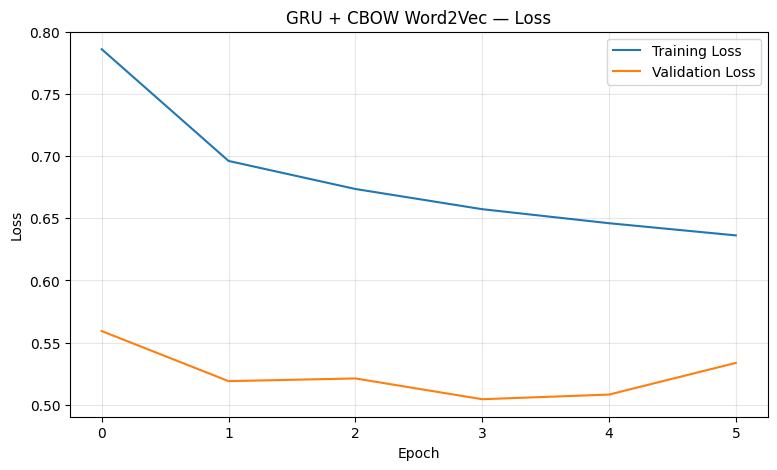

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_gru.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_gru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

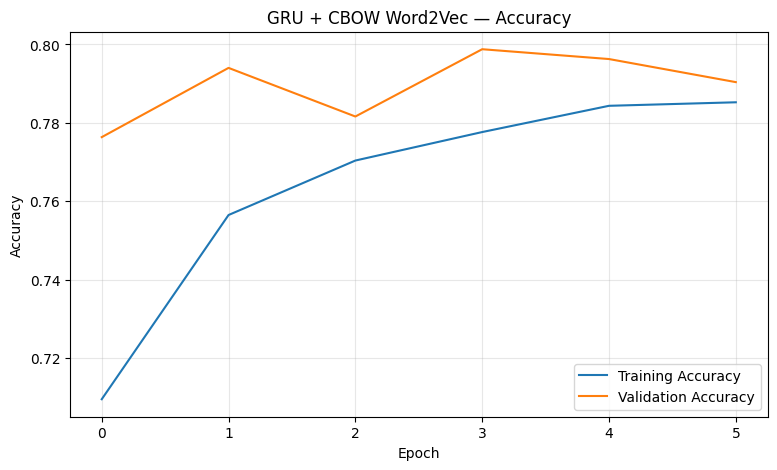

In [53]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_gru.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_gru.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **BiLSTM + Word2Vec**

In [54]:
# ============================================================
# BiLSTM + Word2Vec
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dropout,
    Dense
)

bilstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,907,767 (7.28 MB)

 Trainable params: 235,267 (919.01 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [55]:
early_stopping_bilstm = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_bilstm],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 638s 560ms/step - accuracy: 0.7349 - loss: 0.7382 - val_accuracy: 0.7754 - val_loss: 0.5488
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 624s 555ms/step - accuracy: 0.7672 - loss: 0.6772 - val_accuracy: 0.7554 - val_loss: 0.5784
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 632s 562ms/step - accuracy: 0.7802 - loss: 0.6492 - val_accuracy: 0.7728 - val_loss: 0.5530


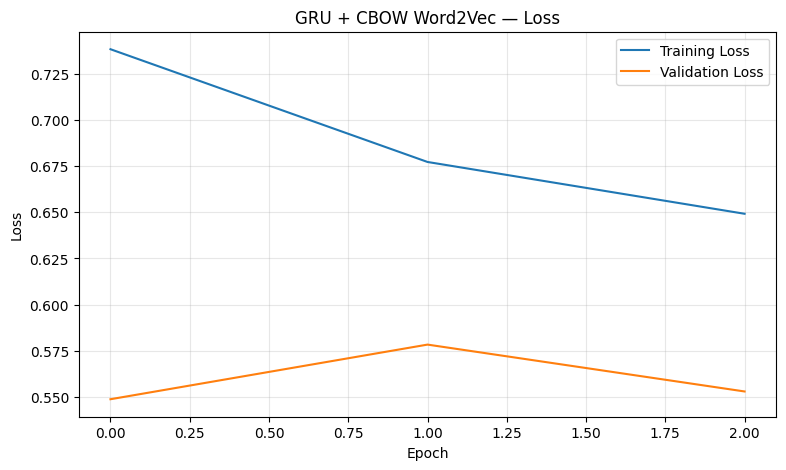

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

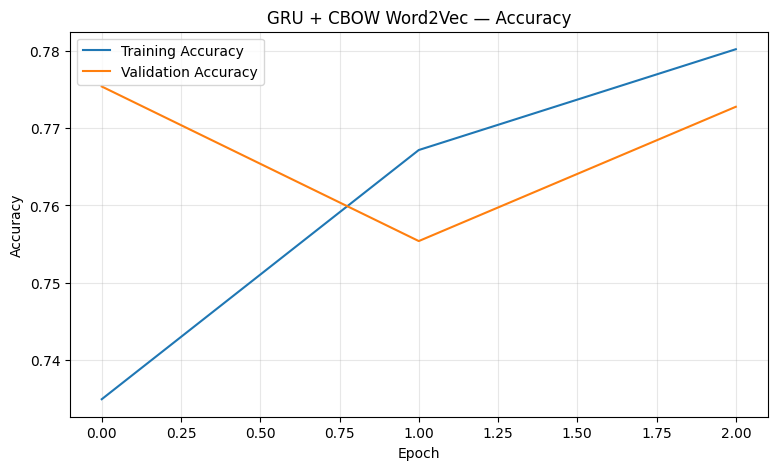

In [57]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [58]:
print("RNN epochs run:", len(history_rnn.history["loss"]))
print("LSTM epochs run:", len(history_lstm.history["loss"]))
print("GRU epochs run:", len(history_gru.history["loss"]))
print("BiLSTM epochs run:", len(history_bilstm.history["loss"]))

RNN epochs run: 3
LSTM epochs run: 5
GRU epochs run: 6
BiLSTM epochs run: 3


In [59]:
import numpy as np

histories = {
    "Simple RNN": history_rnn,
    "LSTM": history_lstm,
    "GRU": history_gru,
    "BiLSTM": history_bilstm
}

for name, history in histories.items():

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_val_loss = np.min(history.history["val_loss"])
    best_val_acc = history.history["val_accuracy"][best_epoch - 1]

    print(f"\n{name}")
    print(f"Best Epoch        : {best_epoch}")
    print(f"Best Validation Loss : {best_val_loss:.4f}")
    print(f"Validation Accuracy  : {best_val_acc:.4f}")


Simple RNN
Best Epoch        : 1
Best Validation Loss : 0.6412
Validation Accuracy  : 0.7492

LSTM
Best Epoch        : 3
Best Validation Loss : 0.4664
Validation Accuracy  : 0.8207

GRU
Best Epoch        : 4
Best Validation Loss : 0.5044
Validation Accuracy  : 0.7988

BiLSTM
Best Epoch        : 1
Best Validation Loss : 0.5488
Validation Accuracy  : 0.7754


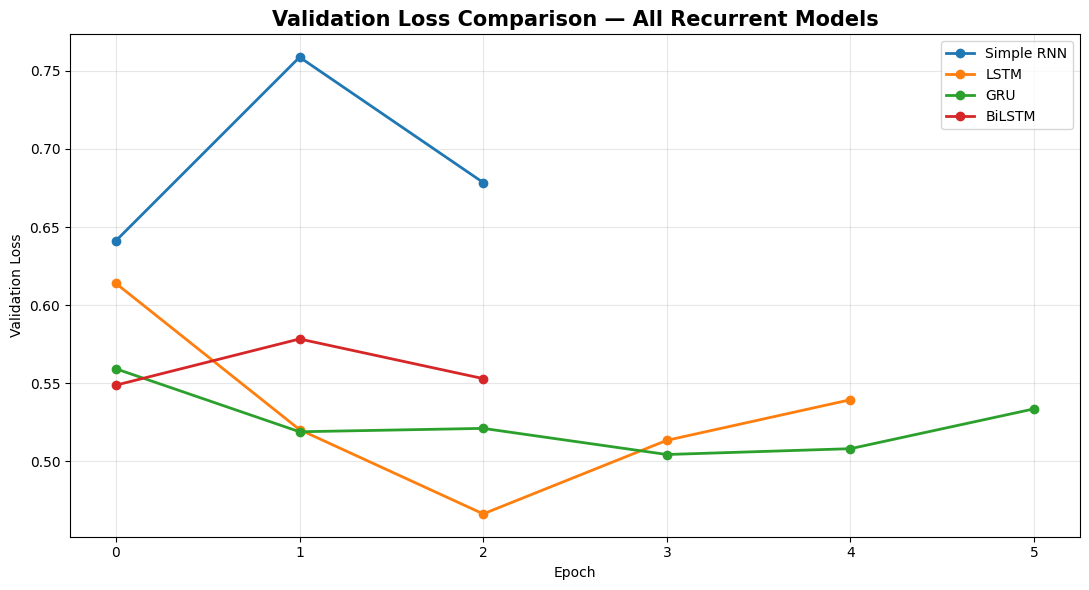

In [60]:
plt.figure(figsize=(11, 6))

plt.plot(
    history_rnn.history["val_loss"],
    marker="o",
    linewidth=2,
    label="Simple RNN"
)

plt.plot(
    history_lstm.history["val_loss"],
    marker="o",
    linewidth=2,
    label="LSTM"
)

plt.plot(
    history_gru.history["val_loss"],
    marker="o",
    linewidth=2,
    label="GRU"
)

plt.plot(
    history_bilstm.history["val_loss"],
    marker="o",
    linewidth=2,
    label="BiLSTM"
)

plt.title(
    "Validation Loss Comparison — All Recurrent Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

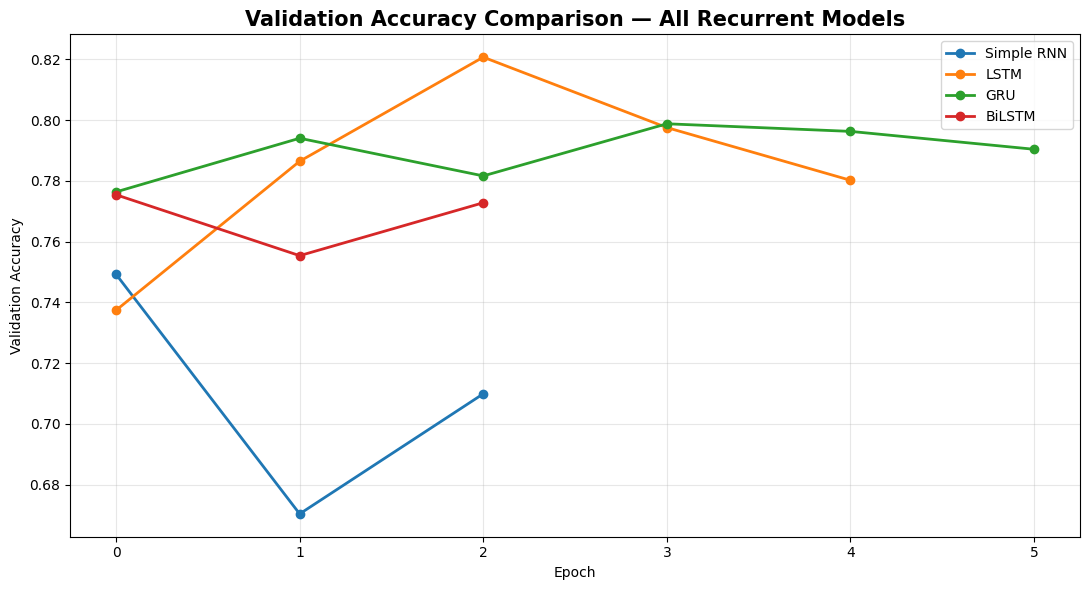

In [61]:
plt.figure(figsize=(11, 6))

plt.plot(
    history_rnn.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Simple RNN"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="LSTM"
)

plt.plot(
    history_gru.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="GRU"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="BiLSTM"
)

plt.title(
    "Validation Accuracy Comparison — All Recurrent Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    # Predict probabilities
    y_prob = model.predict(X_test, batch_size=256, verbose=0)
    
    # Convert probabilities to class predictions
    y_pred = np.argmax(y_prob, axis=1)
    
    print("="*60)
    print(model_name)
    print("="*60)
    
    print(f"Accuracy        : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro Precision : {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro Recall    : {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro F1        : {f1_score(y_test, y_pred, average='macro'):.4f}")
    
    print("\n===== Classification Report =====\n")
    # Changed 'label_encoder.classes_' to 'le.classes_' below
    print(classification_report(
        y_test, 
        y_pred, 
        target_names=le.classes_ 
    ))
    
    return y_pred, y_prob

In [63]:
y_pred_rnn, y_prob_rnn = evaluate_model(
    rnn_model,
    X_test_padded,
    y_test,
    "Simple RNN + Frozen CBOW Word2Vec"
)

Simple RNN + Frozen CBOW Word2Vec
Accuracy        : 0.7504
Macro Precision : 0.5937
Macro Recall    : 0.6340
Macro F1        : 0.5829

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.67      0.59      0.63      6927
     Neutral       0.17      0.50      0.25      2604
    Positive       0.95      0.81      0.87     30399

    accuracy                           0.75     39930
   macro avg       0.59      0.63      0.58     39930
weighted avg       0.85      0.75      0.79     39930



In [64]:
y_pred_lstm, y_prob_lstm = evaluate_model(
    lstm_model,
    X_test_padded,
    y_test,
    "LSTM + Frozen CBOW Word2Vec"
)

LSTM + Frozen CBOW Word2Vec
Accuracy        : 0.8247
Macro Precision : 0.6462
Macro Recall    : 0.7053
Macro F1        : 0.6600

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.74      0.76      0.75      6927
     Neutral       0.23      0.49      0.32      2604
    Positive       0.96      0.87      0.91     30399

    accuracy                           0.82     39930
   macro avg       0.65      0.71      0.66     39930
weighted avg       0.88      0.82      0.85     39930



In [65]:
y_pred_gru, y_prob_gru = evaluate_model(
    gru_model,
    X_test_padded,
    y_test,
    "GRU + Frozen CBOW Word2Vec"
)

GRU + Frozen CBOW Word2Vec
Accuracy        : 0.8020
Macro Precision : 0.6467
Macro Recall    : 0.7182
Macro F1        : 0.6534

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75      6927
     Neutral       0.21      0.57      0.31      2604
    Positive       0.97      0.83      0.90     30399

    accuracy                           0.80     39930
   macro avg       0.65      0.72      0.65     39930
weighted avg       0.88      0.80      0.83     39930



In [66]:
y_pred_bilstm, y_prob_bilstm = evaluate_model(
    bilstm_model,
    X_test_padded,
    y_test,
    "BiLSTM + Frozen CBOW Word2Vec"
)

BiLSTM + Frozen CBOW Word2Vec
Accuracy        : 0.7793
Macro Precision : 0.6270
Macro Recall    : 0.7014
Macro F1        : 0.6328

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.72      0.75      0.73      6927
     Neutral       0.19      0.55      0.29      2604
    Positive       0.97      0.81      0.88     30399

    accuracy                           0.78     39930
   macro avg       0.63      0.70      0.63     39930
weighted avg       0.87      0.78      0.82     39930



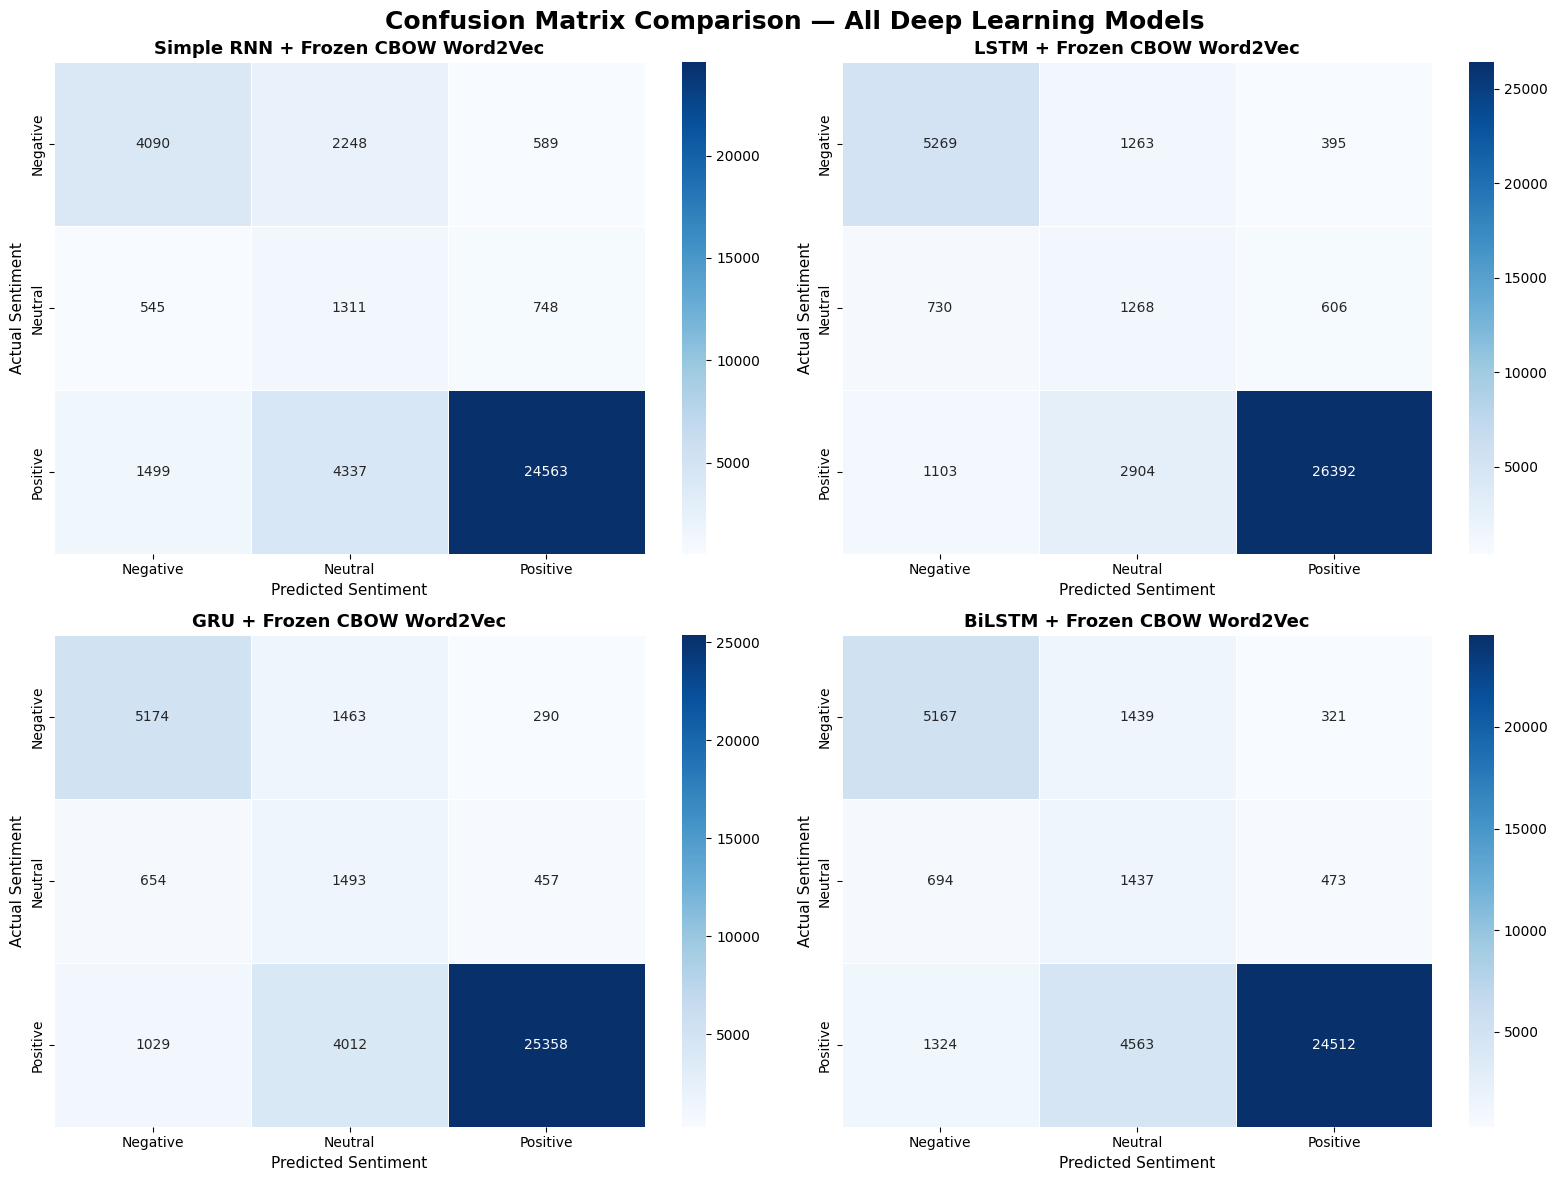

In [67]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Model names and predictions
models_predictions = {
    "Simple RNN + Frozen CBOW Word2Vec": y_pred_rnn,
    "LSTM + Frozen CBOW Word2Vec": y_pred_lstm,
    "GRU + Frozen CBOW Word2Vec": y_pred_gru,
    "BiLSTM + Frozen CBOW Word2Vec": y_pred_bilstm
}

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, models_predictions.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues",
        xticklabels=le.classes_,  # <-- Changed label_encoder to le
        yticklabels=le.classes_,  # <-- Changed label_encoder to le
        cbar=True,
        ax=ax,
        linewidths=0.5,
        linecolor="white"
    )
    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Sentiment", fontsize=11)
    ax.set_ylabel("Actual Sentiment", fontsize=11)

# Overall title
fig.suptitle(
    "Confusion Matrix Comparison — All Deep Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [68]:
# BiLSTM + Fine-tuned CBOW Word2Vec

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)

NUM_CLASSES = 3

bilstm_finetune_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Start with our pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,        
        trainable=True
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

bilstm_finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_finetune_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,907,767 (7.28 MB)

 Trainable params: 1,907,767 (7.28 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
early_stopping_bilstm_finetune = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)

history_bilstm_finetune = bilstm_finetune_model.fit(

    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=15,

    batch_size=128,

    class_weight=class_weights,

    callbacks=[
        early_stopping_bilstm_finetune
    ],

    verbose=1
)

Epoch 1/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 699s 616ms/step - accuracy: 0.7312 - loss: 0.7489 - val_accuracy: 0.7799 - val_loss: 0.5560
Epoch 2/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 685s 609ms/step - accuracy: 0.7703 - loss: 0.6742 - val_accuracy: 0.7656 - val_loss: 0.5773
Epoch 3/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 685s 610ms/step - accuracy: 0.7844 - loss: 0.6417 - val_accuracy: 0.8100 - val_loss: 0.4851
Epoch 4/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 680s 605ms/step - accuracy: 0.7986 - loss: 0.6107 - val_accuracy: 0.7945 - val_loss: 0.5122
Epoch 5/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 691s 615ms/step - accuracy: 0.8082 - loss: 0.5840 - val_accuracy: 0.8008 - val_loss: 0.5095
Epoch 6/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 692s 616ms/step - accuracy: 0.8184 - loss: 0.5598 - val_accuracy: 0.8154 - val_loss: 0.4716
Epoch 7/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 685s 610ms/step - accuracy: 0.8277 - loss: 0.5304 - val_accuracy: 0.8130 - val_loss: 0.4811
Epoch 8/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 685s 609ms/step - ac

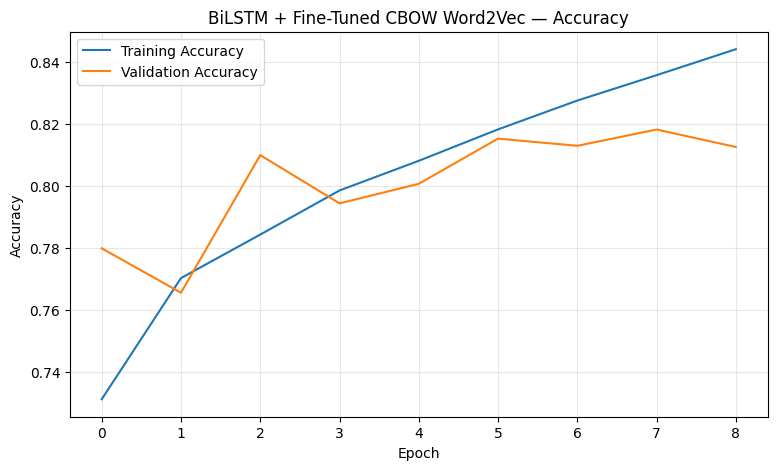

In [70]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm_finetune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bilstm_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM + Fine-Tuned CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [71]:
y_pred_bilstm_finetune, y_prob_bilstm_finetune = evaluate_model(

    bilstm_finetune_model,

    X_test_padded,

    y_test,

    "BiLSTM + Fine-Tuned CBOW Word2Vec"
)

BiLSTM + Fine-Tuned CBOW Word2Vec
Accuracy        : 0.8169
Macro Precision : 0.6534
Macro Recall    : 0.7175
Macro F1        : 0.6618

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.76      0.75      0.76      6927
     Neutral       0.23      0.55      0.32      2604
    Positive       0.97      0.86      0.91     30399

    accuracy                           0.82     39930
   macro avg       0.65      0.72      0.66     39930
weighted avg       0.89      0.82      0.84     39930



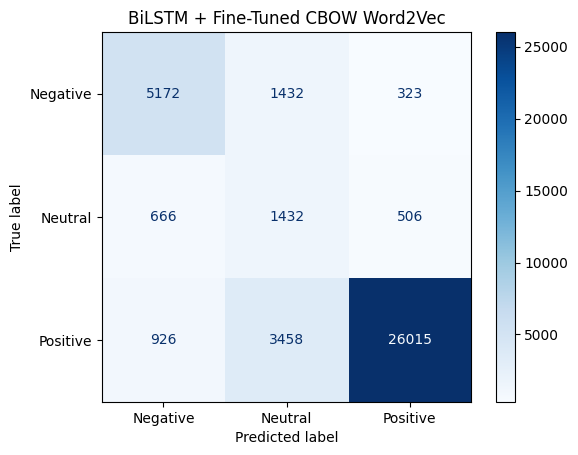

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_bilstm_finetune, 
    display_labels=le.classes_, 
    cmap='Blues'
)
plt.title("BiLSTM + Fine-Tuned CBOW Word2Vec")
plt.show()

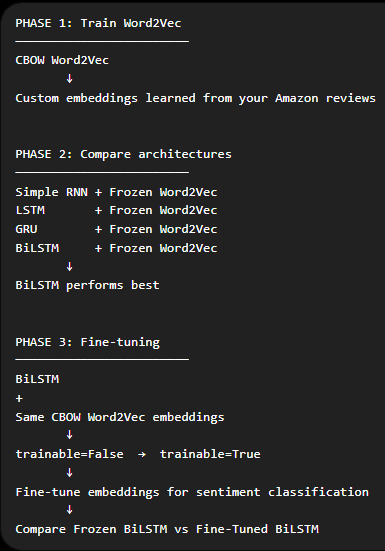

# **ROC_AUC,PR_AUC**

In [75]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score

# Convert true labels into one-hot/binary format
y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

# ============================
# ROC-AUC
# ============================

roc_auc_macro = roc_auc_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    multi_class="ovr",
    average="macro"
)

# ============================
# PR-AUC
# ============================

pr_auc_macro = average_precision_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    average="macro"
)

print("ROC-AUC (Macro):", round(roc_auc_macro, 4))
print("PR-AUC  (Macro):", round(pr_auc_macro, 4))

ROC-AUC (Macro): 0.916
PR-AUC  (Macro): 0.6916


In [76]:
from sklearn.metrics import roc_auc_score

# Changed label_encoder to le
class_names = le.classes_ 

roc_auc_per_class = roc_auc_score(
    y_test_bin, 
    y_prob_bilstm_finetune, 
    multi_class="ovr", 
    average=None
)

for class_name, score in zip(class_names, roc_auc_per_class):
    print(f"{class_name} ROC-AUC: {score:.4f}")

Negative ROC-AUC: 0.9590
Neutral ROC-AUC: 0.8342
Positive ROC-AUC: 0.9547


In [77]:
from sklearn.metrics import average_precision_score

pr_auc_per_class = average_precision_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    average=None
)

for class_name, score in zip(class_names, pr_auc_per_class):
    print(f"{class_name} PR-AUC: {score:.4f}")

Negative PR-AUC: 0.8439
Neutral PR-AUC: 0.2470
Positive PR-AUC: 0.9839


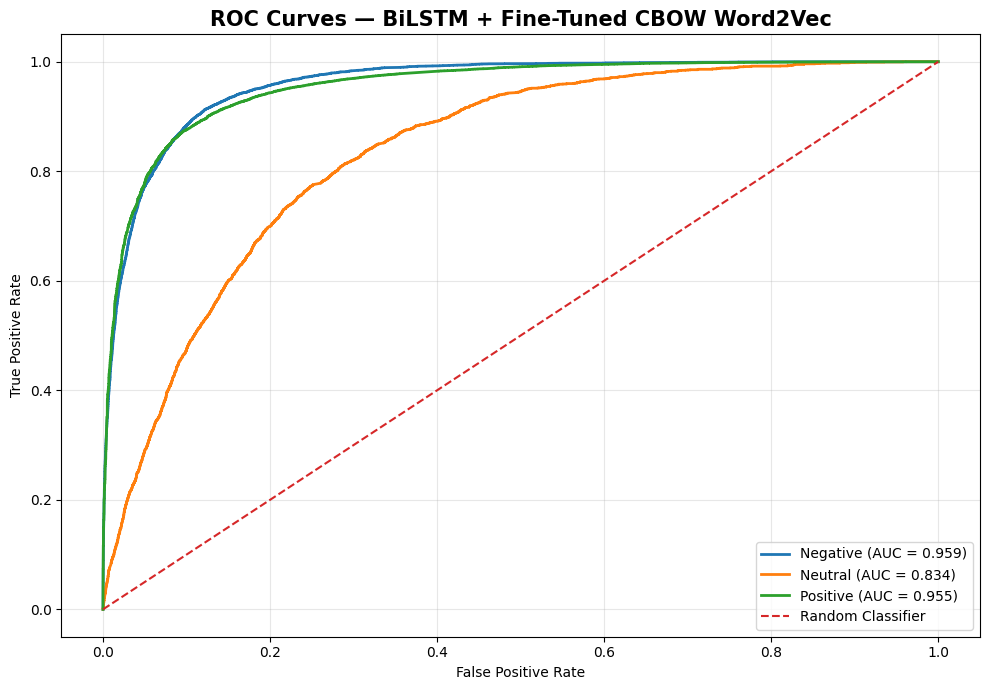

In [78]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_bilstm_finetune[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc_per_class[i]:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "ROC Curves — BiLSTM + Fine-Tuned CBOW Word2Vec",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

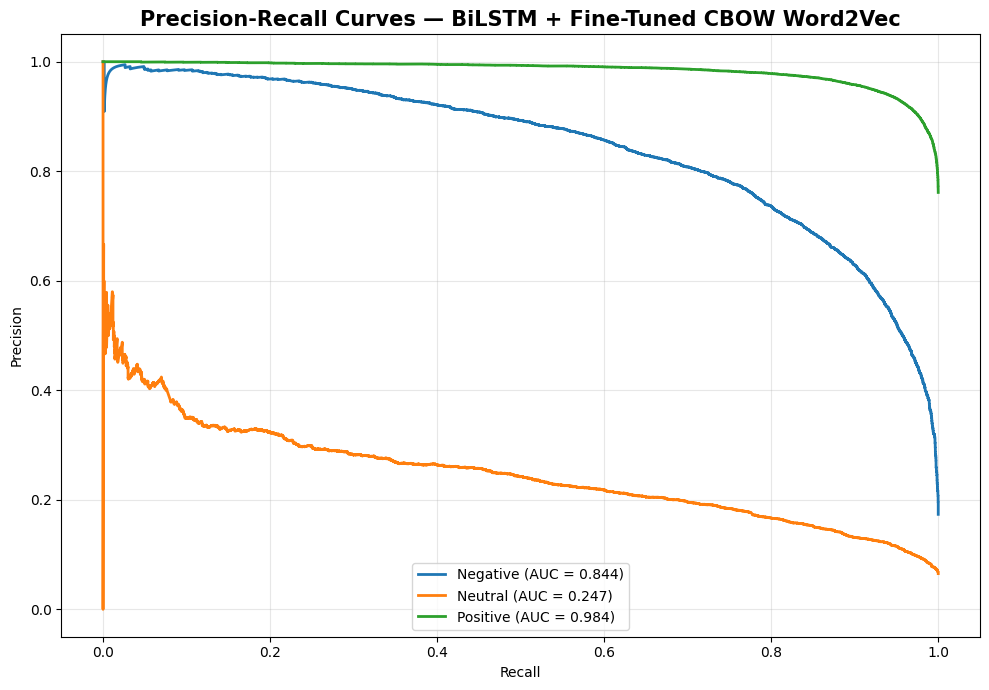

In [79]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(class_names):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob_bilstm_finetune[:, i]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_name} (AUC = {pr_auc_per_class[i]:.3f})"
    )

plt.title(
    "Precision-Recall Curves — BiLSTM + Fine-Tuned CBOW Word2Vec",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [81]:
# Frozen BiLSTM

roc_auc_frozen = roc_auc_score(
    y_test_bin,
    y_prob_bilstm,
    multi_class="ovr",
    average="macro"
)

pr_auc_frozen = average_precision_score(
    y_test_bin,
    y_prob_bilstm,
    average="macro"
)


# Fine-tuned BiLSTM

roc_auc_finetuned = roc_auc_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    multi_class="ovr",
    average="macro"
)

pr_auc_finetuned = average_precision_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    average="macro"
)


print("===== BiLSTM Comparison =====")

print(f"\nFrozen Word2Vec")
print(f"ROC-AUC : {roc_auc_frozen:.4f}")
print(f"PR-AUC  : {pr_auc_frozen:.4f}")

print(f"\nFine-Tuned Word2Vec")
print(f"ROC-AUC : {roc_auc_finetuned:.4f}")
print(f"PR-AUC  : {pr_auc_finetuned:.4f}")

===== BiLSTM Comparison =====

Frozen Word2Vec
ROC-AUC : 0.9017
PR-AUC  : 0.6693

Fine-Tuned Word2Vec
ROC-AUC : 0.9160
PR-AUC  : 0.6916


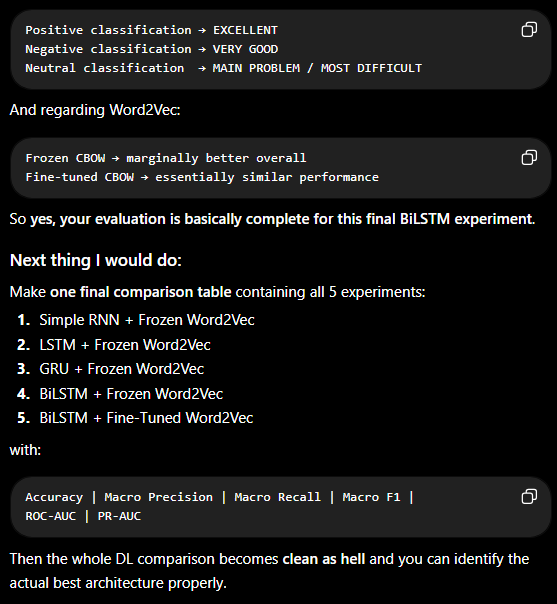

In [167]:
#prediction Time 

text = """
I have been using this product for almost two months now, and my experience has been a bit complicated. At first, I was really impressed with the overall design and the way it worked. The setup was easy, the performance was smooth, and the battery life was much better than I expected. I also liked the screen and found the sound quality perfectly acceptable for everyday use.

However, after using it for a longer period, I started noticing a few problems. Sometimes the device becomes slow for no obvious reason, and on a few occasions it failed to connect properly. The camera is decent during the day but performs poorly in low light. I also feel that the build quality could have been better considering the amount of money I paid for it.

That said, it still does most of the things I need it to do, and I have not faced any major issue that makes the product completely unusable. I am not sure whether I would buy the same product again, but for now I will continue using it and see how it performs over the next few months.
"""

In [168]:
import re
import string
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data (safe to run, it skips if already downloaded)
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize these OUTSIDE the function so they don't reload for every single review
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_the_text(text):
    # Make sure input is a string
    text = str(text)
    
    # =====================================
    # 0. LOWERCASE
    # =====================================
    text = text.lower()
    
    # =====================================
    # 1. HTML TAG REMOVAL
    # =====================================
    text = BeautifulSoup(text, "html.parser").get_text()
    
    # =====================================
    # 2. URL REMOVAL
    # =====================================
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # =====================================
    # 3. PUNCTUATION REMOVAL
    # =====================================
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # =====================================
    # 4. EXTRA WHITESPACE REMOVAL
    # =====================================
    text = re.sub(r"\s+", " ", text).strip()
    
    # =====================================
    # 5. TOKENIZATION
    # =====================================
    tokens = text.split()
    
    # =====================================
    # 6. STOPWORD REMOVAL
    # =====================================
    tokens = [word for word in tokens if word not in stop_words]
    
    # =====================================
    # 7. LEMMATIZATION
    # =====================================
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # =====================================
    # 8. JOIN WORDS BACK
    # =====================================
    cleaned_text = " ".join(tokens)
    
    return cleaned_text

# Test the function with your text variable from Cell 82
print(clean_the_text(text))

using product almost two month experience bit complicated first really impressed overall design way worked setup easy performance smooth battery life much better expected also liked screen found sound quality perfectly acceptable everyday use however using longer period started noticing problem sometimes device becomes slow obvious reason occasion failed connect properly camera decent day performs poorly low light also feel build quality could better considering amount money paid said still thing need faced major issue make product completely unusable sure whether would buy product continue using see performs next month


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [169]:
def text_to_sequence(text):
    text = str(text)

    return [
        word_to_index[word]
        for word in text.split()
        if word in word_to_index
    ]

In [170]:
cleaned_text = clean_the_text(text)

print("Original text :", text)
print("Cleaned text  :", cleaned_text)

Original text : 
I have been using this product for almost two months now, and my experience has been a bit complicated. At first, I was really impressed with the overall design and the way it worked. The setup was easy, the performance was smooth, and the battery life was much better than I expected. I also liked the screen and found the sound quality perfectly acceptable for everyday use.

However, after using it for a longer period, I started noticing a few problems. Sometimes the device becomes slow for no obvious reason, and on a few occasions it failed to connect properly. The camera is decent during the day but performs poorly in low light. I also feel that the build quality could have been better considering the amount of money I paid for it.

That said, it still does most of the things I need it to do, and I have not faced any major issue that makes the product completely unusable. I am not sure whether I would buy the same product again, but for now I will continue using it a

In [171]:
sequence = text_to_sequence(cleaned_text)

print("Integer sequence:", sequence)

Integer sequence: [31, 8, 54, 325, 97, 1964, 20, 437, 149, 206, 55, 53, 181, 13, 367, 684, 25, 135, 33, 150, 429, 39, 10, 11, 90, 1599, 1120, 5, 31, 225, 981, 301, 4079, 40, 35, 470, 1854, 266, 1911, 599, 162, 501, 18, 334, 52, 1387, 1522, 215, 56, 91, 397, 11, 33, 730, 4402, 85, 485, 223, 5016, 36, 26, 7352, 897, 43, 38, 8, 329, 1596, 105, 34, 8, 1264, 31, 3678, 1387, 54]


In [172]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

sequence_padded = pad_sequences(
    [sequence],
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(sequence_padded)
print(sequence_padded.shape)

[[  31    8   54  325   97 1964   20  437  149  206   55   53  181   13
   367  684   25  135   33  150  429   39   10   11   90 1599 1120    5
    31  225  981  301 4079   40   35  470 1854  266 1911  599  162  501
    18  334   52 1387 1522  215   56   91  397   11   33  730 4402   85
   485  223 5016   36   26 7352  897   43   38    8  329 1596  105   34
     8 1264   31 3678 1387   54    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]]
(1, 100)


In [173]:
prediction_probabilities = bilstm_finetune_model.predict(
    sequence_padded
)

print(prediction_probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
[[0.8256177  0.1599189  0.01446348]]


In [174]:
import numpy as np

class_names = ["Negative", "Neutral", "Positive"]

predicted_class = np.argmax(prediction_probabilities, axis=1)[0]
predicted_sentiment = class_names[predicted_class]
confidence = prediction_probabilities[0][predicted_class]

print("Predicted Sentiment:", predicted_sentiment)
print(f"Confidence: {confidence:.2%}")

Predicted Sentiment: Negative
Confidence: 82.56%
